# Phase 1: Tomato Freshness Detection Machine Learning Pipeline
### Non-Destructive Quality Estimation using Multispectral Sensing

This notebook contains the complete, production-ready Machine Learning development pipeline for **Phase 1** of the Tomato Freshness Detection System.

The system uses multispectral sensor readings captured by an **AS7341 Spectral Sensor** mounted on an **ESP32** microcontroller, together with engineered vegetation indices, to predict:
1. **Freshness Score** (Regression target: 0-100)
2. **Freshness Category** (Classification target: e.g., Fresh, Aging, Spoiling)

---

### Table of Contents
1. **Library Imports & Setup**
2. **Dataset Loading & Initial Inspection**
3. **Data Validation & Target Leakage Detection**
4. **Exploratory Data Analysis (EDA)**
5. **Feature Engineering & Multicollinearity (VIF) Checking**
6. **Data Preprocessing & Train/Val/Test Split**
7. **Model Benchmarking & Selection**
8. **Feature Importance & Selection Analysis**
9. **Hyperparameter Optimization (Tuning)**
10. **Model Evaluation & Visualizations**
11. **Model Explainability (SHAP Analysis)**
12. **Pipeline Serialization & Saving**
13. **Production Inference Pipeline**
14. **Continuous Learning & Retraining Pipeline**

## 1. Library Imports & Setup
We import all necessary scientific computing, data manipulation, visualization, modeling, and serialization libraries. We also set seeds for reproducibility.

In [1]:
pip install numpy pandas matplotlib seaborn scipy scikit-learn joblib xgboost lightgbm shap statsmodels SHAP

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install SHAP

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, roc_curve, auc
)

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, ExtraTreesRegressor, ExtraTreesClassifier
import xgboost as xgb

# Conditionally import LightGBM if installed
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False

# Conditionally import SHAP if installed
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Styling parameters
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

print("Libraries loaded successfully.")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM is {'available' if LGBM_AVAILABLE else 'not available'}.")
print(f"SHAP is {'available' if SHAP_AVAILABLE else 'not available'}.")

Libraries loaded successfully.
XGBoost version: 3.3.0
LightGBM is available.
SHAP is available.


## 2. Dataset Loading & Initial Inspection
We load the synthetic dataset, print its dimensions, and show descriptive structural details.

In [4]:
DATA_PATH = "Tomato_Multispectral_Realistic_100k.csv"

print(f"Attempting to load dataset from: {DATA_PATH}")
try:
    df = pd.read_csv(DATA_PATH)
    print("✔ Dataset loaded successfully.")
except FileNotFoundError:
    # Fallback to subdirectory structure if run from root directory
    df = pd.read_csv("ml model/Tomato_Multispectral_Realistic_100k.csv")
    print("✔ Dataset loaded from subdirectory folder successfully.")

print(f"Dataset dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nDataset Columns and Types:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Attempting to load dataset from: Tomato_Multispectral_Realistic_100k.csv
✔ Dataset loaded successfully.
Dataset dimensions: 100000 rows, 13 columns

Dataset Columns and Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Tomato_ID        100000 non-null  int64  
 1   Tomato_position  100000 non-null  int64  
 2   Blue             100000 non-null  float64
 3   Green            100000 non-null  float64
 4   Yellow           100000 non-null  float64
 5   Orange           100000 non-null  float64
 6   Red              100000 non-null  float64
 7   NIR              100000 non-null  float64
 8   NDVI             100000 non-null  float64
 9   GNDVI            100000 non-null  float64
 10  RVI              100000 non-null  float64
 11  Freshness_       100000 non-null  float64
 12  Category         100000 non-null  object 
dtypes: f

,Tomato_ID,Tomato_position,Blue,Green,Yellow,Orange,Red,NIR,NDVI,GNDVI,RVI,Freshness_,Category
0,1,1,49.58,46.34,47.89,111.31,180.62,145.87,-0.1065,0.5178,0.8076,19.14,Spoiling
1,1,2,32.36,32.68,41.03,135.68,157.76,77.41,-0.3417,0.4063,0.4907,13.55,Spoiling
2,1,3,34.21,27.73,36.39,98.35,134.78,85.18,-0.2255,0.5089,0.6320,17.64,Spoiling
3,1,4,20.74,28.33,26.82,112.29,139.16,176.00,0.1169,0.7227,1.2648,29.89,Spoiling
4,1,5,33.68,36.07,32.04,109.98,153.98,119.85,-0.1247,0.5373,0.7783,19.10,Spoiling



Last 5 rows:


,Tomato_ID,Tomato_position,Blue,Green,Yellow,Orange,Red,NIR,NDVI,GNDVI,RVI,Freshness_,Category
99995,10000,6,48.74,53.93,62.35,58.11,60.75,378.04,0.7231,0.7503,6.2225,59.30,Aging
99996,10000,7,37.43,38.75,43.99,65.69,83.91,338.28,0.6025,0.7944,4.0314,52.99,Aging
99997,10000,8,50.81,52.66,57.84,65.16,79.74,351.58,0.6303,0.7395,4.4093,53.89,Aging
99998,10000,9,36.88,47.21,40.94,53.98,67.90,352.87,0.6772,0.7640,5.1965,56.44,Aging
99999,10000,10,43.84,46.51,48.02,82.74,105.37,311.53,0.4945,0.7402,2.9566,46.95,Aging


## 3. Data Validation & Target Leakage Detection
Data validation is crucial when shifting from synthetic data to physical ESP32 readings. Here, we run checks to:
- Confirm presence of all required bands and indices.
- Check for physical validity (no negative values for spectral readings).
- Check index consistency (NDVI, GNDVI, RVI) against their exact formulas.
- Detect target leakage (no features showing near 100% correlation with target scores).

In [5]:
def validate_dataset(df):
    required_cols = ["Blue", "Green", "Yellow", "Orange", "Red", "NIR", "NDVI", "GNDVI", "RVI", "Freshness_", "Category"]
    
    # 1. Required Columns presence
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"CRITICAL: Missing columns in dataset: {missing}")
    print("✔ All required columns are present in the dataset.")
    
    # 2. Sensor range verification (Spectral bands must be positive)
    spectral_bands = ["Blue", "Green", "Yellow", "Orange", "Red", "NIR"]
    negative_bands = (df[spectral_bands] < 0).sum()
    if negative_bands.sum() > 0:
        print(f"⚠ WARNING: Negative sensor values detected:\n{negative_bands[negative_bands > 0]}")
    else:
        print("✔ Sensor bands range validation passed (all values are non-negative).")
        
    # 3. Target Leakage check
    leakage_flag = False
    for col in spectral_bands + ["NDVI", "GNDVI", "RVI"]:
        corr = abs(df[col].corr(df["Freshness_"]))
        if corr > 0.98:
            print(f"⚠ WARNING: High correlation ({corr:.4f}) between feature '{col}' and target 'Freshness_'. Possible target leakage!")
            leakage_flag = True
    if not leakage_flag:
        print("✔ Target leakage check passed: Features show reasonable correlation levels.")
        
    # 4. Mathematical index consistency checks
    # Formula checks: NDVI = (NIR - Red) / (NIR + Red)
    epsilon = 1e-8
    calc_ndvi = (df["NIR"] - df["Red"]) / (df["NIR"] + df["Red"] + epsilon)
    ndvi_mae = np.mean(np.abs(df["NDVI"] - calc_ndvi))
    print(f"Index consistency check: NDVI MAE vs Formula = {ndvi_mae:.6f}")
    
    # GNDVI = (NIR - Green) / (NIR + Green)
    calc_gndvi = (df["NIR"] - df["Green"]) / (df["NIR"] + df["Green"] + epsilon)
    gndvi_mae = np.mean(np.abs(df["GNDVI"] - calc_gndvi))
    print(f"Index consistency check: GNDVI MAE vs Formula = {gndvi_mae:.6f}")
    
    # RVI = NIR / Red
    calc_rvi = df["NIR"] / (df["Red"] + epsilon)
    rvi_mae = np.mean(np.abs(df["RVI"] - calc_rvi))
    print(f"Index consistency check: RVI MAE vs Formula = {rvi_mae:.6f}")
    
    if ndvi_mae > 0.02 or gndvi_mae > 0.02 or rvi_mae > 0.02:
        print("⚠ WARNING: Discrepancies found in vegetation index calculations. Please check calculation logic.")
    else:
        print("✔ Vegetation indices formulas are mathematically consistent with sensor bands.")

validate_dataset(df)

✔ All required columns are present in the dataset.
✔ Sensor bands range validation passed (all values are non-negative).
⚠ WARNING: High correlation (0.9807) between feature 'NIR' and target 'Freshness_'. Possible target leakage!
Index consistency check: NDVI MAE vs Formula = 0.000027
Index consistency check: GNDVI MAE vs Formula = 0.000028
Index consistency check: RVI MAE vs Formula = 0.000336
✔ Vegetation indices formulas are mathematically consistent with sensor bands.


## 4. Exploratory Data Analysis (EDA)
We run descriptive summaries, evaluate missing values, examine the distribution of targets, check correlations, and display outlier ratios.

In [6]:
# Missing values and duplicates
print("=== Missing Values Summary ===")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print(f"\nDuplicate rows in dataset: {duplicates}")

# Constant values check
constant_columns = [c for c in df.columns if df[c].nunique() == 1]
print(f"Constant columns: {constant_columns}")

# Statistical summary table
print("\n=== Descriptive Statistics ===")
display(df.describe().T)

=== Missing Values Summary ===
Tomato_ID          0
Tomato_position    0
Blue               0
Green              0
Yellow             0
Orange             0
Red                0
NIR                0
NDVI               0
GNDVI              0
RVI                0
Freshness_         0
Category           0
dtype: int64

Duplicate rows in dataset: 0
Constant columns: []

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
Tomato_ID,100000.0,5000.500000,2886.765765,1.0000,2500.750000,5000.50000,7500.250000,10000.0000
Tomato_position,100000.0,5.500000,2.872296,1.0000,3.000000,5.50000,8.000000,10.0000
Blue,100000.0,44.714735,13.620306,2.0000,35.160000,44.70000,54.130000,140.0000
Green,100000.0,47.588932,12.980118,2.0000,38.330000,47.64000,56.790000,160.0000
Yellow,100000.0,45.774381,13.401313,2.0000,36.410000,45.81000,55.050000,149.2200
Orange,100000.0,73.011124,27.371677,3.0000,52.040000,72.54000,93.600000,220.0000
Red,100000.0,86.718481,34.375723,3.0000,59.260000,85.97000,113.540000,260.0000
NIR,100000.0,311.806006,119.945287,24.3400,213.557500,312.16000,411.820000,750.0000
NDVI,100000.0,0.504468,0.294677,-0.7113,0.309900,0.56780,0.746600,0.9889
GNDVI,100000.0,0.716067,0.080052,-0.3405,0.683700,0.73550,0.769000,0.9689


Plotting feature distributions (Histograms + Boxplots)... 


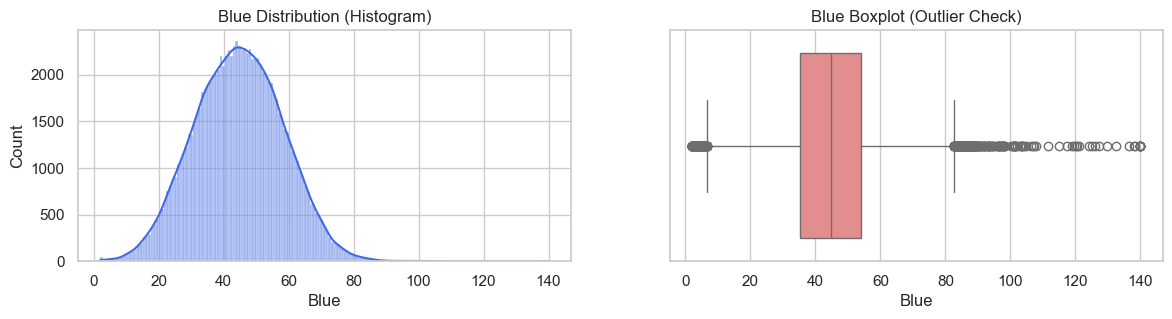

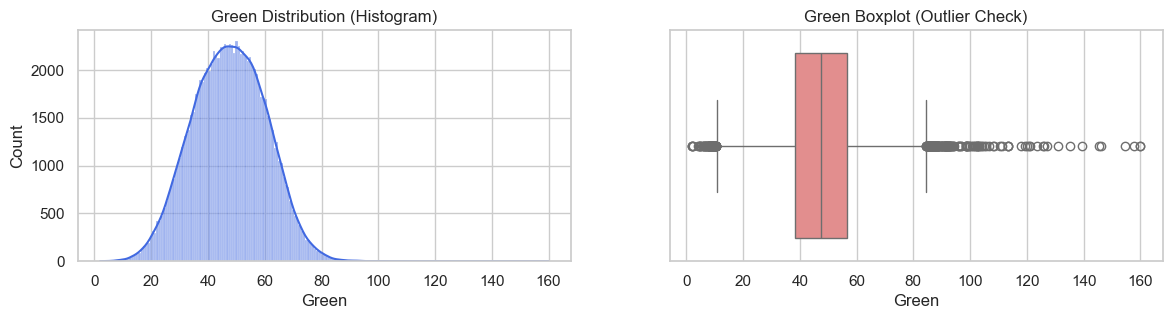

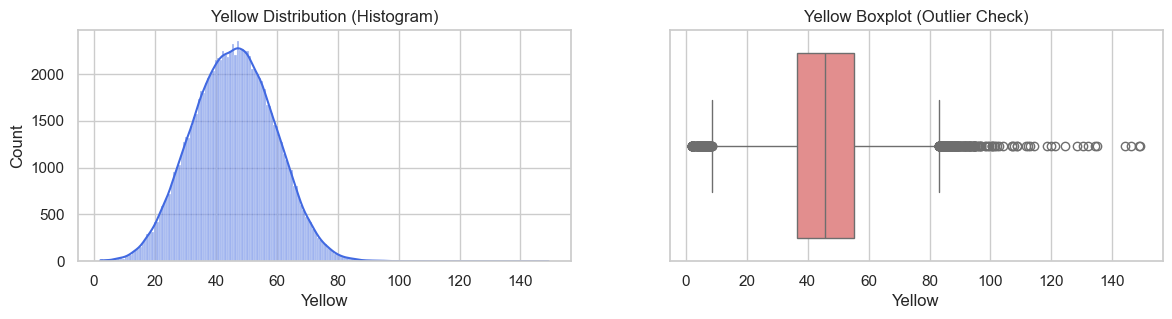

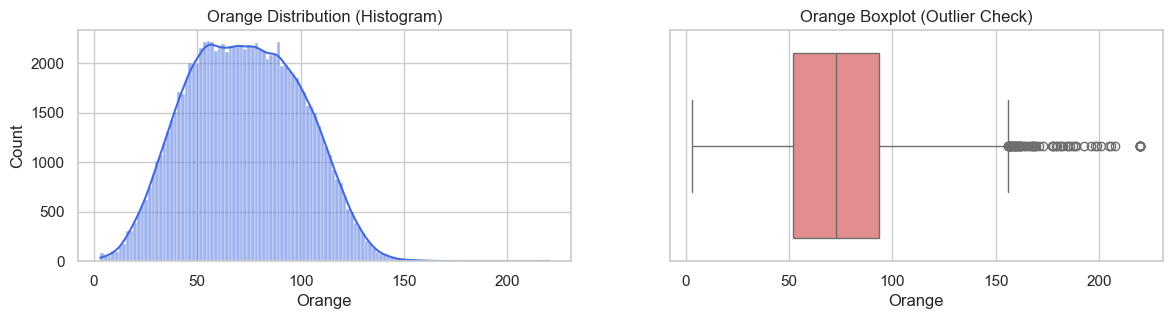

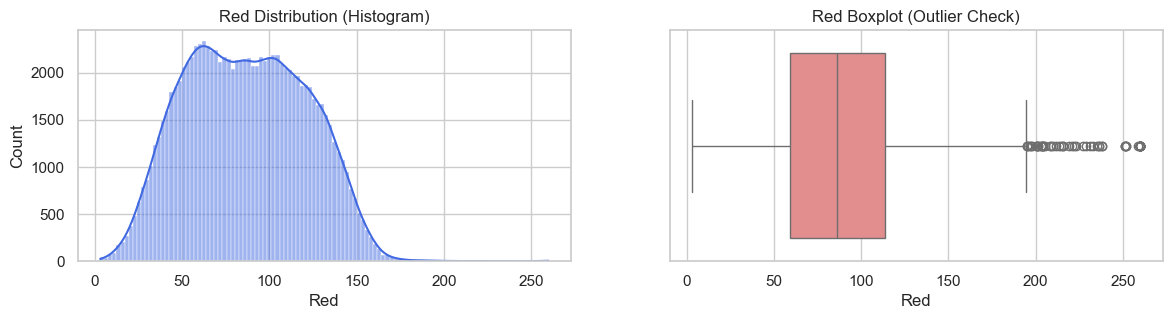

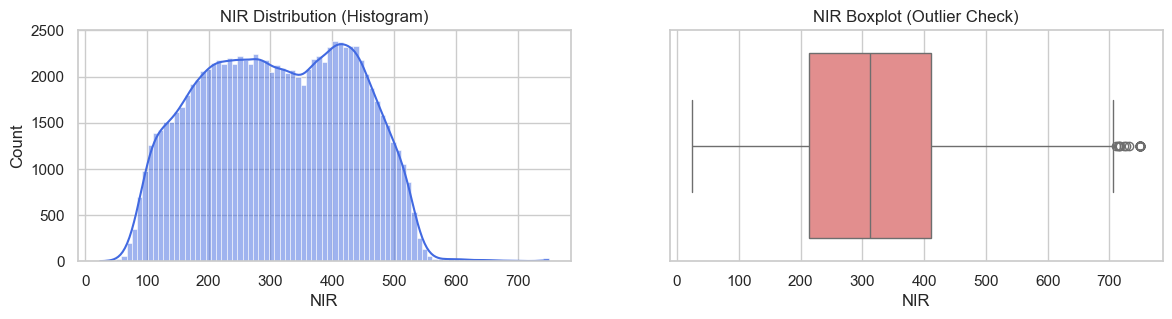

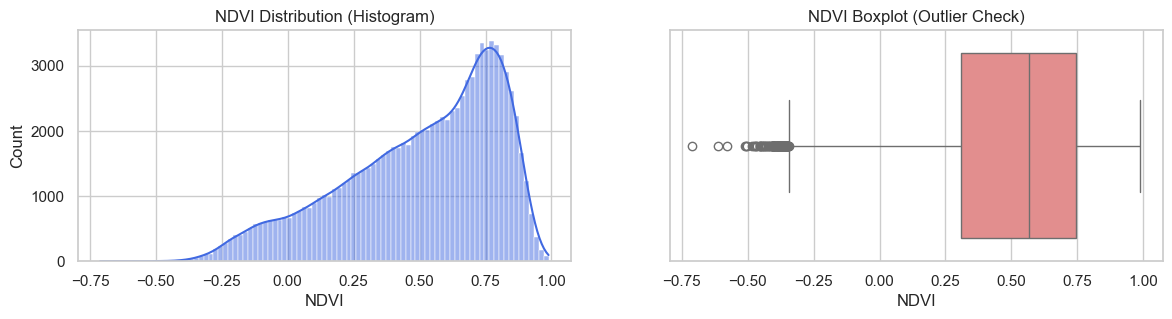

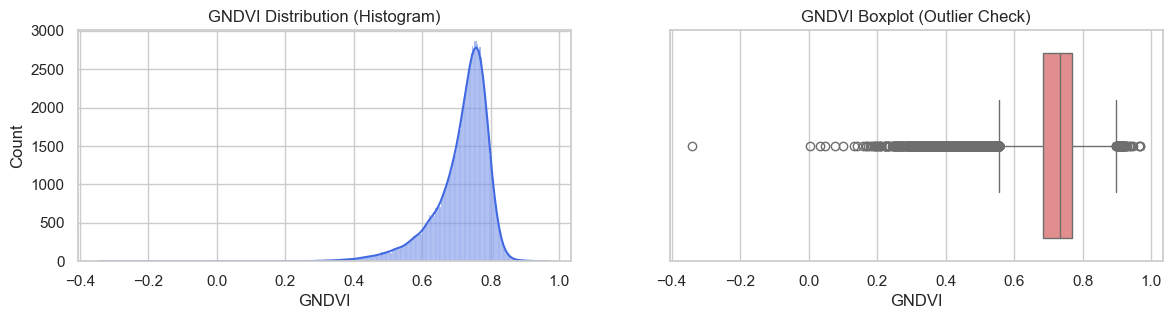

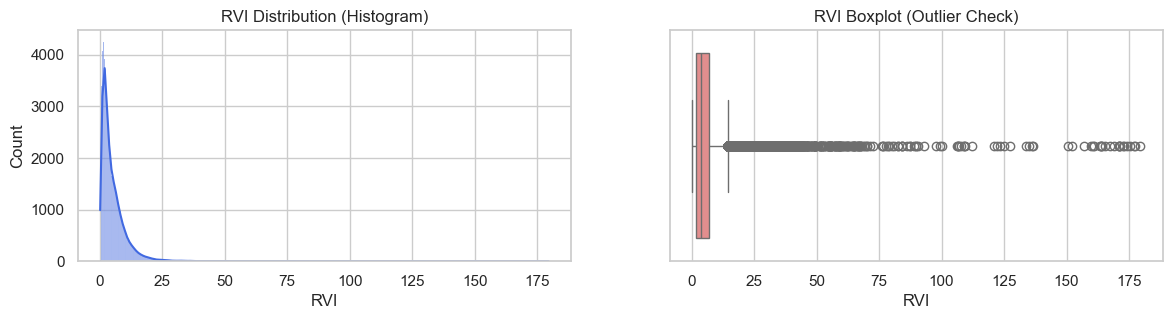

In [7]:
# Visualizing distributions
features = ["Blue", "Green", "Yellow", "Orange", "Red", "NIR", "NDVI", "GNDVI", "RVI"]

print("Plotting feature distributions (Histograms + Boxplots)... ")
for f in features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    sns.histplot(df[f], kde=True, ax=axes[0], color="royalblue")
    axes[0].set_title(f"{f} Distribution (Histogram)")
    
    sns.boxplot(x=df[f], ax=axes[1], color="lightcoral")
    axes[1].set_title(f"{f} Boxplot (Outlier Check)")
    plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16880\3818530979.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Category"], ax=axes[1], palette="magma")


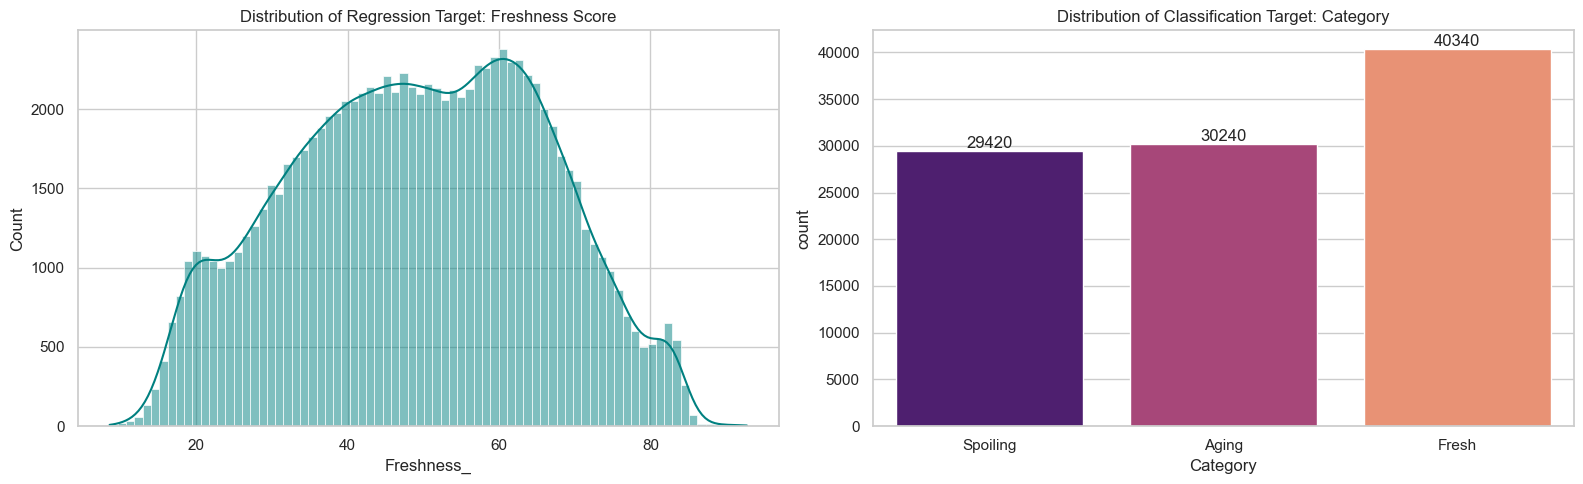

Class distribution proportions:
Category
Fresh       0.4034
Aging       0.3024
Spoiling    0.2942
Name: proportion, dtype: float64


In [8]:
# Target Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Regression target (Freshness score)
sns.histplot(df["Freshness_"], kde=True, color="teal", ax=axes[0])
axes[0].set_title("Distribution of Regression Target: Freshness Score")

# 2. Classification target (Category)
sns.countplot(x=df["Category"], ax=axes[1], palette="magma")
axes[1].set_title("Distribution of Classification Target: Category")
for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()
plt.show()

print("Class distribution proportions:")
print(df["Category"].value_counts(normalize=True))

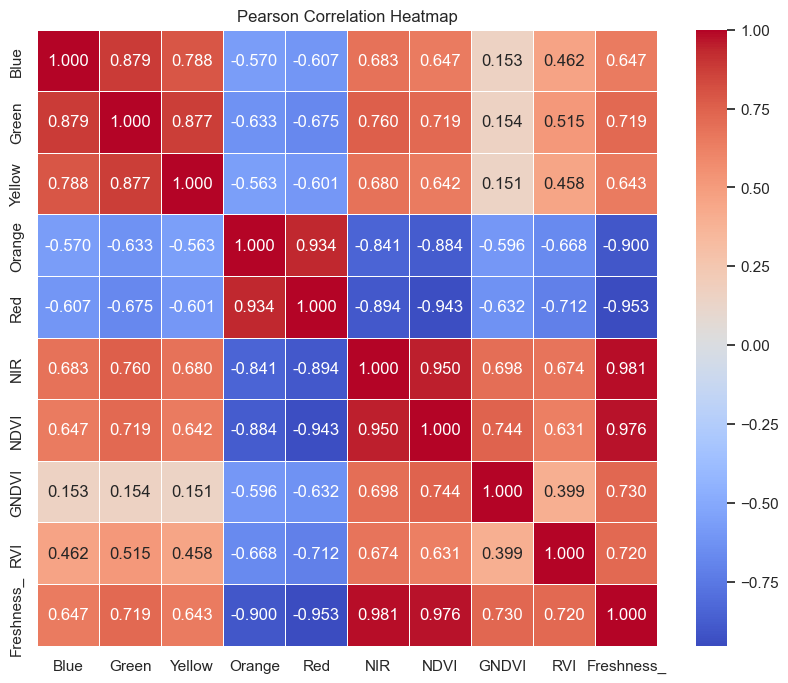

Correlation scores with Freshness Score:
Freshness_    1.000000
NIR           0.980696
NDVI          0.976116
GNDVI         0.729834
RVI           0.720032
Green         0.718600
Blue          0.647082
Yellow        0.642766
Orange       -0.899877
Red          -0.953037
Name: Freshness_, dtype: float64


In [9]:
# Correlation analysis
corr = df[features + ["Freshness_"]].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5)
plt.title("Pearson Correlation Heatmap")
plt.show()

print("Correlation scores with Freshness Score:")
print(corr["Freshness_"].sort_values(ascending=False))

In [10]:
# Outlier analysis using IQR
def summarize_outliers_iqr(df, features_list):
    summary = {}
    for col in features_list:
        q25 = np.percentile(df[col], 25)
        q75 = np.percentile(df[col], 75)
        iqr = q75 - q25
        threshold = iqr * 1.5
        lower = q25 - threshold
        upper = q75 + threshold
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        summary[col] = {
            "outliers_count": len(outliers),
            "outliers_percentage": f"{(len(outliers) / len(df)) * 100:.2f}%"
        }
    return pd.DataFrame(summary).T

outliers_df = summarize_outliers_iqr(df, features)
display(outliers_df)

,outliers_count,outliers_percentage
Blue,404,0.40%
Green,258,0.26%
Yellow,407,0.41%
Orange,78,0.08%
Red,62,0.06%
NIR,39,0.04%
NDVI,126,0.13%
GNDVI,5012,5.01%
RVI,4992,4.99%


## 5. Feature Engineering & Multicollinearity Validation
We check Variance Inflation Factors (VIF) to assess multicollinearity among features. Highly correlated features (e.g. Red vs. NIR vs. indices) will exhibit high VIF values. While tree models tolerate this, low multicollinearity yields higher interpretability for linear/explaining models and cleaner deployments.

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create VIF dataset including features plus intercept
VIF_df = df[features].copy()
VIF_df["intercept"] = 1.0

vif_scores = pd.DataFrame()
vif_scores["feature"] = VIF_df.columns
vif_scores["VIF"] = [variance_inflation_factor(VIF_df.values, i) for i in range(len(VIF_df.columns))]

# Filter out intercept
vif_scores = vif_scores[vif_scores["feature"] != "intercept"]
print("=== Variance Inflation Factor (VIF) ===")
display(vif_scores.sort_values(by="VIF", ascending=True))

=== Variance Inflation Factor (VIF) ===


,feature,VIF
8,RVI,2.408414
2,Yellow,4.378849
0,Blue,4.428097
3,Orange,7.800317
7,GNDVI,14.596519
5,NIR,18.303332
1,Green,19.466161
4,Red,24.310205
6,NDVI,52.126479


## 6. Data Preprocessing & Split
We isolate features and target variables, split the data into **Train (70%)**, **Validation (15%)**, and **Test (15%)** sets, encode classification categories, and set up preprocessing pipelines.

In [12]:
# Drop unused columns (identifiers)
X = df[features].copy()
y_reg = df["Freshness_"].copy()
y_clf_raw = df["Category"].copy()

# Encode target classes
le = LabelEncoder()
y_clf = le.fit_transform(y_clf_raw)
class_names = le.classes_
print(f"Target class mapping: {dict(zip(range(len(class_names)), class_names))}")

# Train/Val/Test Split (70/15/15)
# Step 1: Split train and temporary validation/test split (80-20 temporary is common, here we use exactly 30% temp to achieve 15/15)
X_train, X_temp, y_train_reg, y_temp_reg, y_train_clf, y_temp_clf = train_test_split(
    X, y_reg, y_clf, test_size=0.30, random_state=RANDOM_SEED, stratify=y_clf
)

# Step 2: Split temp into 50% validation and 50% test
X_val, X_test, y_val_reg, y_test_reg, y_val_clf, y_test_clf = train_test_split(
    X_temp, y_temp_reg, y_temp_clf, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp_clf
)

print(f"Train size: {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size: {X_test.shape}")

# Setup a preprocessing pipeline using ColumnTransformer
# Standard scaling is defined but not mandatory for tree-based models
preprocessor = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), features)
    ],
    remainder='passthrough'
)

# Fit preprocessor
preprocessor.fit(X_train)
print("✔ Preprocessor configured and fitted.")

Target class mapping: {0: 'Aging', 1: 'Fresh', 2: 'Spoiling'}
Train size: (70000, 9)
Validation size: (15000, 9)
Test size: (15000, 9)
✔ Preprocessor configured and fitted.


## 7. Model Benchmarking & Selection
We benchmark several regression and classification models using validation data:
- Decision Tree
- Random Forest
- Extra Trees
- XGBoost
- LightGBM (if available)

We select the model yielding the highest validation metrics.

In [13]:
# Initialize regression models
regressors = {
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_SEED),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=RANDOM_SEED, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=50, random_state=RANDOM_SEED, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
}

if LGBM_AVAILABLE:
    regressors["LightGBM"] = lgb.LGBMRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)

# Initialize classification models
classifiers = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=RANDOM_SEED, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=50, random_state=RANDOM_SEED, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, eval_metric='mlogloss', random_state=RANDOM_SEED, n_jobs=-1)
}

if LGBM_AVAILABLE:
    classifiers["LightGBM"] = lgb.LGBMClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)

# Evaluate Regressors
reg_scores = []
print("=== Training & Evaluating Regressors ===")
for name, model in regressors.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_reg)
    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_val_reg, preds))
    r2 = r2_score(y_val_reg, preds)
    reg_scores.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2})

df_reg_scores = pd.DataFrame(reg_scores).sort_values(by="R2 Score", ascending=False)
display(df_reg_scores)

# Evaluate Classifiers
clf_scores = []
print("\n=== Training & Evaluating Classifiers ===")
for name, model in classifiers.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_clf)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val_clf, preds)
    p, r, f1, _ = precision_recall_fscore_support(y_val_clf, preds, average='weighted')
    clf_scores.append({"Model": name, "Accuracy": acc, "Weighted F1": f1, "Weighted Precision": p, "Weighted Recall": r})

df_clf_scores = pd.DataFrame(clf_scores).sort_values(by="Weighted F1", ascending=False)
display(df_clf_scores)

# Selection of Best Model
best_reg_name = df_reg_scores.iloc[0]["Model"]
best_clf_name = df_clf_scores.iloc[0]["Model"]
print(f"\n✔ Selected Best Regressor: {best_reg_name}")
print(f"✔ Selected Best Classifier: {best_clf_name}")

=== Training & Evaluating Regressors ===
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training XGBoost...
Training LightGBM...


,Model,MAE,RMSE,R2 Score
2,Extra Trees,0.116481,0.185127,0.999875
4,LightGBM,0.135197,0.194519,0.999862
1,Random Forest,0.128666,0.212593,0.999835
3,XGBoost,0.156534,0.217468,0.999828
0,Decision Tree,0.243142,0.345067,0.999566



=== Training & Evaluating Classifiers ===
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training XGBoost...
Training LightGBM...


,Model,Accuracy,Weighted F1,Weighted Precision,Weighted Recall
4,LightGBM,0.800200,0.799686,0.799339,0.800200
3,XGBoost,0.798667,0.798066,0.797606,0.798667
1,Random Forest,0.793200,0.793177,0.793301,0.793200
2,Extra Trees,0.791600,0.791390,0.791369,0.791600
0,Decision Tree,0.725600,0.725690,0.725780,0.725600



✔ Selected Best Regressor: Extra Trees
✔ Selected Best Classifier: LightGBM


## 8. Feature Importance & Selection Analysis
Using the trained XGBoost model, we analyze feature importances. If certain spectral bands are of low importance, we can prune them to speed up inference and save power on ESP32 resource-constrained configurations.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16880\2686822828.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_reg.values, y=importances_reg.index, ax=axes[0], palette="viridis")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_16880\2686822828.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_clf.values, y=importances_clf.index, ax=axes[1], palette="plasma")


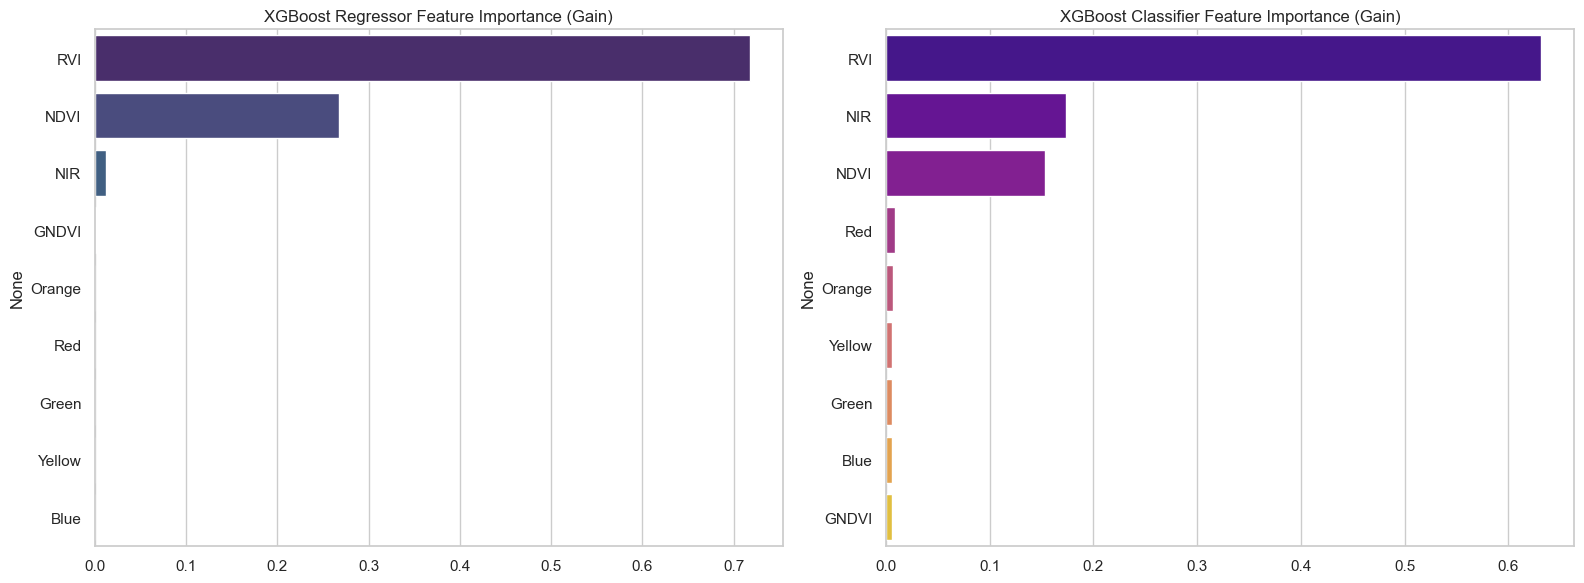

Regression Feature Selection:
Features meeting threshold (>=0.015): ['RVI', 'NDVI']
Pruned features: ['Blue', 'Green', 'Yellow', 'Orange', 'Red', 'NIR', 'GNDVI']

Classification Feature Selection:
Features meeting threshold (>=0.015): ['RVI', 'NIR', 'NDVI']
Pruned features: ['Blue', 'Green', 'Yellow', 'Orange', 'Red', 'GNDVI']


In [14]:
# Get XGBoost Feature Importance
xgb_reg_model = regressors["XGBoost"]
xgb_clf_model = classifiers["XGBoost"]

importances_reg = pd.Series(xgb_reg_model.feature_importances_, index=features).sort_values(ascending=False)
importances_clf = pd.Series(xgb_clf_model.feature_importances_, index=features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=importances_reg.values, y=importances_reg.index, ax=axes[0], palette="viridis")
axes[0].set_title("XGBoost Regressor Feature Importance (Gain)")

sns.barplot(x=importances_clf.values, y=importances_clf.index, ax=axes[1], palette="plasma")
axes[1].set_title("XGBoost Classifier Feature Importance (Gain)")

plt.tight_layout()
plt.show()

# Utility for automated feature selection
def select_top_features(importances, threshold=0.015):
    selected = importances[importances >= threshold].index.tolist()
    print(f"Features meeting threshold (>={threshold}): {selected}")
    print(f"Pruned features: {[f for f in features if f not in selected]}")
    return selected

print("Regression Feature Selection:")
selected_features_reg = select_top_features(importances_reg)

print("\nClassification Feature Selection:")
selected_features_clf = select_top_features(importances_clf)

## 9. Hyperparameter Optimization
We optimize hyperparameters of the primary XGBoost models using `RandomizedSearchCV` cross-validation.

In [15]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0.0, 0.1, 0.2]
}

print("=== Optimizing Hyperparameters for XGBoost Regressor ===")
cv_reg = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=5, # Keep run-time fast during phase 1 execution
    scoring='r2',
    cv=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)
cv_reg.fit(X_train, y_train_reg)
best_regressor = cv_reg.best_estimator_
print(f"Best Regressor Parameters: {cv_reg.best_params_}")

print("\n=== Optimizing Hyperparameters for XGBoost Classifier ===")
cv_clf = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(random_state=RANDOM_SEED, n_jobs=-1, eval_metric='mlogloss'),
    param_distributions=param_grid,
    n_iter=5,
    scoring='accuracy',
    cv=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)
cv_clf.fit(X_train, y_train_clf)
best_classifier = cv_clf.best_estimator_
print(f"Best Classifier Parameters: {cv_clf.best_params_}")

=== Optimizing Hyperparameters for XGBoost Regressor ===
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Regressor Parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.0, 'colsample_bytree': 0.8}

=== Optimizing Hyperparameters for XGBoost Classifier ===
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Classifier Parameters: {'subsample': 0.8, 'n_estimators': 150, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 1.0}


## 10. Model Evaluation & Visualizations
We evaluate the optimized models against the held-out **Test Set**.

=== Regression Test Set Evaluation ===
MAE:  0.1043
MSE:  0.0249
RMSE: 0.1578
R2:   0.9999


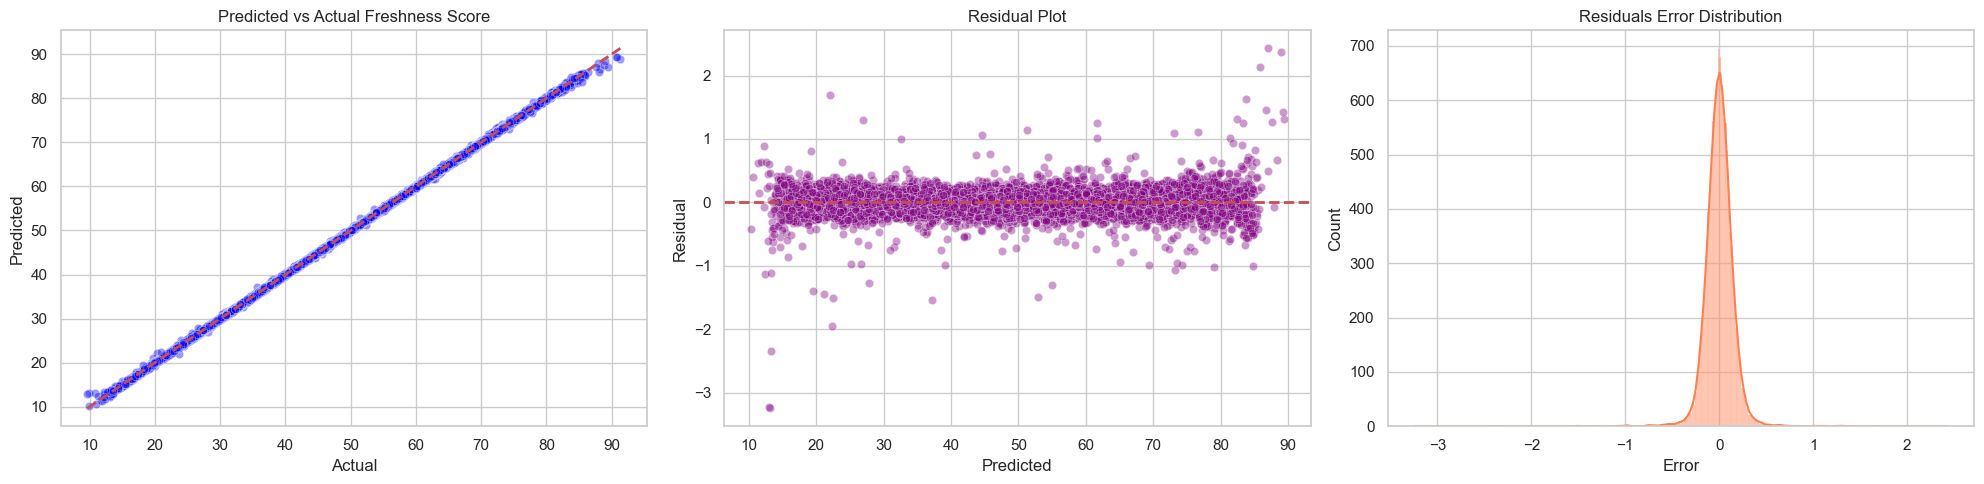

In [16]:
# 1. Regressor Evaluation
test_preds_reg = best_regressor.predict(X_test)
mae = mean_absolute_error(y_test_reg, test_preds_reg)
mse = mean_squared_error(y_test_reg, test_preds_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, test_preds_reg)

print("=== Regression Test Set Evaluation ===")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# Plot actual vs predicted & residuals
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.scatterplot(x=y_test_reg, y=test_preds_reg, alpha=0.4, color="blue", ax=axes[0])
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_title("Predicted vs Actual Freshness Score")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

residuals = y_test_reg - test_preds_reg
sns.scatterplot(x=test_preds_reg, y=residuals, alpha=0.4, color="purple", ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

sns.histplot(residuals, kde=True, color="coral", ax=axes[2])
axes[2].set_title("Residuals Error Distribution")
axes[2].set_xlabel("Error")

plt.tight_layout()
plt.show()

=== Classification Test Set Evaluation ===
Accuracy Score: 0.8087

Classification Report:
              precision    recall  f1-score   support

       Aging       0.69      0.68      0.69      4536
       Fresh       0.88      0.90      0.89      6051
    Spoiling       0.83      0.81      0.82      4413

    accuracy                           0.81     15000
   macro avg       0.80      0.80      0.80     15000
weighted avg       0.81      0.81      0.81     15000



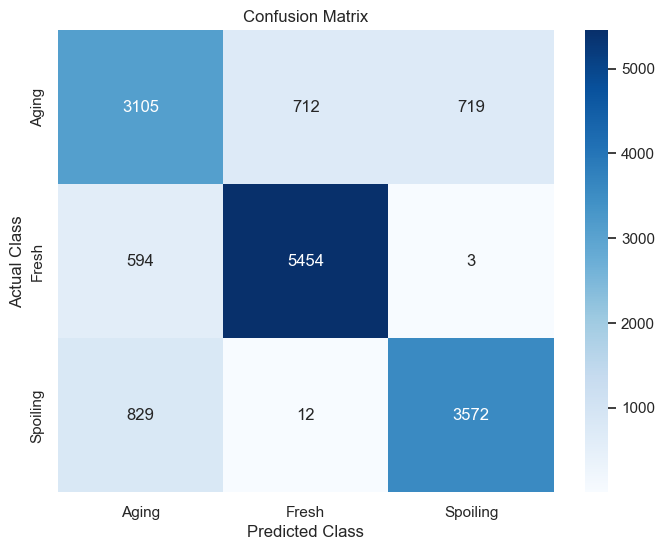

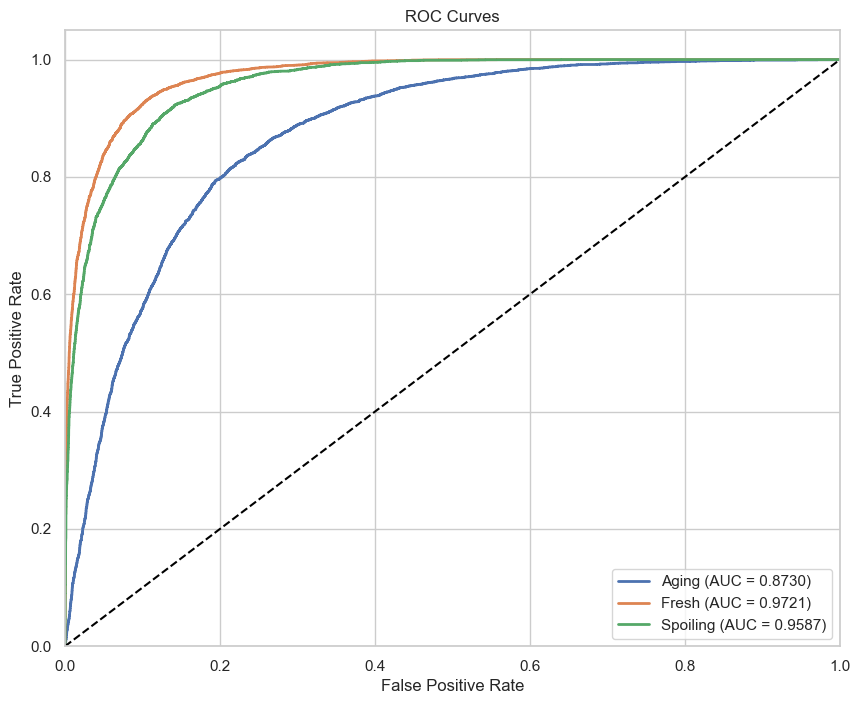

In [17]:
# 2. Classifier Evaluation
test_preds_clf = best_classifier.predict(X_test)
test_probs_clf = best_classifier.predict_proba(X_test)
acc = accuracy_score(y_test_clf, test_preds_clf)

print("=== Classification Test Set Evaluation ===")
print(f"Accuracy Score: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test_clf, test_preds_clf, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test_clf, test_preds_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# ROC-AUC Curves
plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve((y_test_clf == i).astype(int), test_probs_clf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], color="black", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.show()

## 11. Model Explainability
We use SHAP (SHapley Additive exPlanations) values to identify how specific spectral bands influence tomato freshness prediction.

In [18]:
import shap
print(shap.__version__)


0.52.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16880\3917658324.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, shap_sample, show=False)


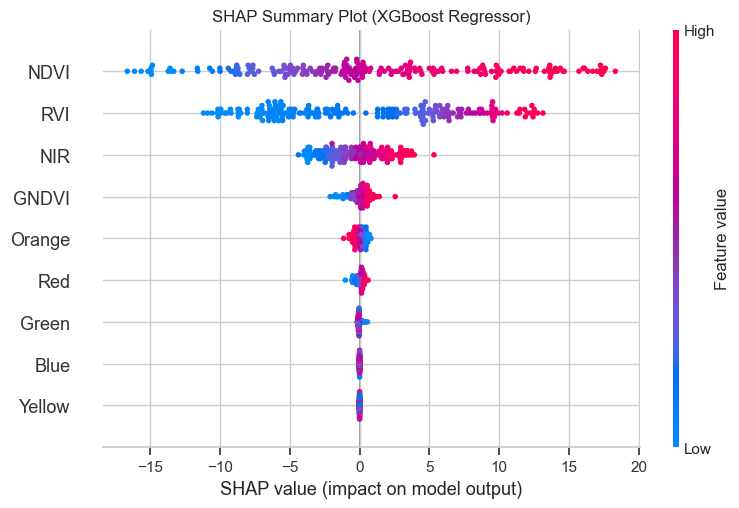

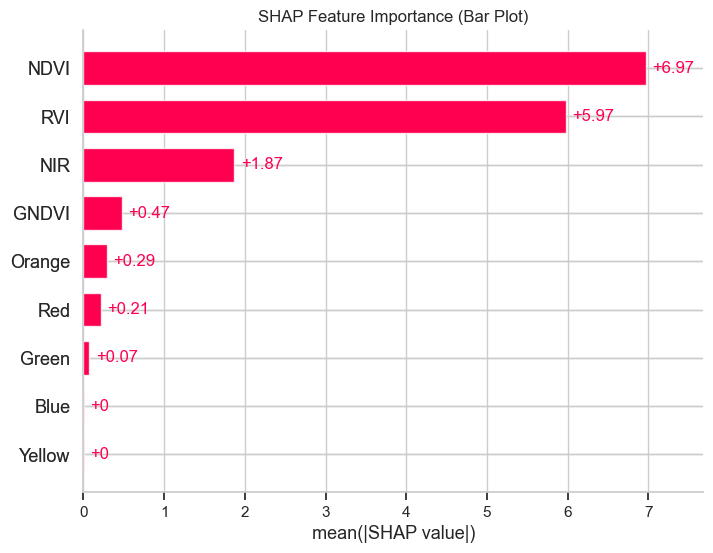

In [19]:
if SHAP_AVAILABLE:
    # Initialize SHAP TreeExplainer
    explainer = shap.TreeExplainer(best_regressor)
    # Select a subset of test records for faster computation
    shap_sample = X_test.sample(200, random_state=RANDOM_SEED)
    shap_vals = explainer(shap_sample)
    
    # Summary Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, shap_sample, show=False)
    plt.title("SHAP Summary Plot (XGBoost Regressor)")
    plt.show()
    
    # Bar Plot
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_vals, show=False)
    plt.title("SHAP Feature Importance (Bar Plot)")
    plt.show()
else:
    print("SHAP library is not installed. Plotting XGBoost F-Score (gain) values instead.")
    xgb.plot_importance(best_regressor, importance_type="gain", grid=False, color="salmon")
    plt.title("XGBoost Regressor Feature Importance (Gain)")
    plt.show()

## 12. Save Models & Assets
We serialize the trained models, preprocessing structures, encoders, feature checklist, and training metrics in a pipeline dictionary.

In [20]:
os.makedirs("models", exist_ok=True)

# Define overall metadata
pipeline_payload = {
    "regressor": best_regressor,
    "classifier": best_classifier,
    "label_encoder": le,
    "preprocessor": preprocessor,
    "features": features,
    "metadata": {
        "dataset_shape": df.shape,
        "classes": list(class_names),
        "regression_r2": r2,
        "classification_accuracy": acc,
        "version": "v1.0"
    }
}

# Export to disk
joblib.dump(pipeline_payload, "models/tomato_freshness_pipeline_v1.pkl")
joblib.dump(best_regressor, "models/xgboost_regressor.pkl")
joblib.dump(best_classifier, "models/xgboost_classifier.pkl")

print("✔ Successfully exported models/xgboost_regressor.pkl, xgboost_classifier.pkl, and models/tomato_freshness_pipeline_v1.pkl")

✔ Successfully exported models/xgboost_regressor.pkl, xgboost_classifier.pkl, and models/tomato_freshness_pipeline_v1.pkl


## 13. Inference Pipeline
This class provides a clean prediction module for deployment. It takes raw spectral values, validates inputs, computes the indices, and calls the models.

In [21]:
class TomatoFreshnessInference:
    def __init__(self, pipeline_path="models/tomato_freshness_pipeline_v1.pkl"):
        self.payload = joblib.load(pipeline_path)
        self.regressor = self.payload["regressor"]
        self.classifier = self.payload["classifier"]
        self.le = self.payload["label_encoder"]
        self.preprocessor = self.payload["preprocessor"]
        self.features = self.payload["features"]
        
    def predict(self, blue, green, yellow, orange, red, nir):
        # 1. Validation
        inputs = [blue, green, yellow, orange, red, nir]
        if any(x < 0 for x in inputs):
            raise ValueError("Sensor input values cannot be negative.")
            
        # Safe calculation of indices
        epsilon = 1e-8
        ndvi = (nir - red) / (nir + red + epsilon)
        gndvi = (nir - green) / (nir + green + epsilon)
        rvi = nir / (red + epsilon)
        
        # Build input dataframe
        input_df = pd.DataFrame([{
            "Blue": blue, "Green": green, "Yellow": yellow, "Orange": orange,
            "Red": red, "NIR": nir, "NDVI": ndvi, "GNDVI": gndvi, "RVI": rvi
        }])
        
        # Enforce column layout
        input_df = input_df[self.features]
        
        # Preprocess if necessary (tree models pass-through, but kept for scaling compatibility)
        # input_scaled = self.preprocessor.transform(input_df)
        
        # 2. Prediction
        score_pred = self.regressor.predict(input_df)[0]
        score_pred = float(np.clip(score_pred, 0, 100)) # clip limits
        
        clf_pred = self.classifier.predict(input_df)[0]
        class_name = self.le.inverse_transform([clf_pred])[0]
        
        probs = self.classifier.predict_proba(input_df)[0]
        confidence = float(np.max(probs))
        
        return {
            "freshness_score": score_pred,
            "freshness_class": class_name,
            "confidence_score": confidence,
            "features": {
                "NDVI": ndvi,
                "GNDVI": gndvi,
                "RVI": rvi
            }
        }

# Run sanity check
pipeline = TomatoFreshnessInference()
sample_res = pipeline.predict(blue=60, green=69, yellow=77, orange=52, red=25, nir=121)
print("Sample Inference Pipeline Output:")
print(json.dumps(sample_res, indent=4))

Sample Inference Pipeline Output:
{
    "freshness_score": 42.44562911987305,
    "freshness_class": "Fresh",
    "confidence_score": 0.6128810048103333,
    "features": {
        "NDVI": 0.6575342465303058,
        "GNDVI": 0.27368421051191133,
        "RVI": 4.839999998064
    }
}


## 14. Continuous Learning & Retraining Pipeline
This pipeline verifies, checks for drift, combines, and retrains the model when new real physical samples (from ESP32) are added.

In [31]:
class ContinuousRetrainingPipeline:
    def __init__(self, current_pipeline_path="models/tomato_freshness_pipeline_v1.1.pkl", models_dir="models"):
        self.pipeline_path = current_pipeline_path
        self.models_dir = models_dir
        self.payload = joblib.load(self.pipeline_path)
        self.features = self.payload["features"]
        
    def check_drift(self, new_data_df, reference_df, significance_level=0.05):
        """
        Performs a two-sample Kolmogorov-Smirnov test to detect distribution differences.
        """
        drift_report = {}
        for f in self.features:
            ks_stat, p_val = stats.ks_2samp(reference_df[f], new_data_df[f])
            drift_report[f] = {
                "ks_stat": float(ks_stat),
                "p_value": float(p_val),
                "drift_detected": bool(p_val < significance_level)
            }
        return drift_report
        
    def validate_new_data(self, new_df):
        # Verify structure
        required = self.features + ["Freshness_", "Category"]
        missing = [c for c in required if c not in new_df.columns]
        if missing:
            return False, f"Missing columns in incoming dataset: {missing}"
            
        # Verify non-negative spectral bands
        spectral = ["Blue", "Green", "Yellow", "Orange", "Red", "NIR"]
        if (new_df[spectral] < 0).any().any():
            return False, "Negative spectral sensor values detected in new dataset."
            
        return True, "Validation successful."
        
    def run_retraining(self, new_data_path, performance_threshold_r2=0.85):
        print("--- Starting Model Retraining Run ---")
        new_df = pd.read_csv(new_data_path)
        
        # 1. Validation
        valid, msg = self.validate_new_data(new_df)
        if not valid:
            print(f"❌ Retraining aborted: {msg}")
            return False
        print("✔ New dataset successfully validated.")
        
        # 2. Check Drift
        ref_df = pd.read_csv("Tomato_Multispectral_Realistic_100k.csv")
        drift_report = self.check_drift(new_df, ref_df)
        drifted = [k for k, v in drift_report.items() if v["drift_detected"]]
        if drifted:
            print(f"⚠ Drift detected in feature distributions: {drifted}")
        else:
            print("✔ No distribution drift detected.")
            
        # 3. Combine
        combined_df = pd.concat([ref_df, new_df], ignore_index=True)
        print(f"Combined training set contains {combined_df.shape[0]} rows.")
        
        # 4. Fit & Split
        X_comb = combined_df[self.features]
        y_comb_reg = combined_df["Freshness_"]
        y_comb_clf_raw = combined_df["Category"]
        
        le_new = LabelEncoder()
        y_comb_clf = le_new.fit_transform(y_comb_clf_raw)
        
        X_tr, X_te, y_tr_reg, y_te_reg, y_tr_clf, y_te_clf = train_test_split(
            X_comb, y_comb_reg, y_comb_clf, test_size=0.20, random_state=RANDOM_SEED
        )
        
        # Retrain
        # Instantiate models with active hyperparameters
        reg_params = self.payload["regressor"].get_params()
        clf_params = self.payload["classifier"].get_params()
        
        print("Fitting new models...")
        new_reg = xgb.XGBRegressor(**reg_params)
        new_reg.fit(X_tr, y_tr_reg)
        
        new_clf = xgb.XGBClassifier(**clf_params)
        new_clf.fit(X_tr, y_tr_clf)
        
        # Evaluate
        new_r2 = r2_score(y_te_reg, new_reg.predict(X_te))
        new_acc = accuracy_score(y_te_clf, new_clf.predict(X_te))
        
        curr_r2 = self.payload["metadata"]["regression_r2"]
        curr_acc = self.payload["metadata"]["classification_accuracy"]
        
        print(f"Current model test score: R2 = {curr_r2:.4f}, Accuracy = {curr_acc:.4f}")
        print(f"Retrained model test score: R2 = {new_r2:.4f}, Accuracy = {new_acc:.4f}")
        
        # Determine Versioning
        curr_version_str = self.payload["metadata"]["version"]
        curr_version_val = float(curr_version_str.replace("v", ""))
        new_version_str = f"v{curr_version_val + 0.1:.1f}"
        
        # Update checks
        if new_r2 >= performance_threshold_r2 and new_r2 >= (curr_r2 - 0.03):
            print(f"✔ Retrained model is viable. Updating active model to version {new_version_str}...")
            
            # Package assets
            new_payload = {
                "regressor": new_reg,
                "classifier": new_clf,
                "label_encoder": le_new,
                "preprocessor": self.payload["preprocessor"],
                "features": self.features,
                "metadata": {
                    "dataset_shape": combined_df.shape,
                    "classes": list(le_new.classes_),
                    "regression_r2": new_r2,
                    "classification_accuracy": new_acc,
                    "version": new_version_str
                }
            }
            
            # Save versioned package
            joblib.dump(new_payload, os.path.join(self.models_dir, f"tomato_freshness_pipeline_{new_version_str}.pkl"))
            
            # Save to production endpoint
            joblib.dump(new_reg, os.path.join(self.models_dir, "xgboost_regressor.pkl"))
            joblib.dump(new_clf, os.path.join(self.models_dir, "xgboost_classifier.pkl"))
            print("✔ Deployed updated active model parameters to xgboost_regressor.pkl and xgboost_classifier.pkl.")
            return True
        else:
            print("❌ Retrained model did not meet validation performance criteria. Previous model retained.")
            return False

cl_pipeline = ContinuousRetrainingPipeline()
print("Continuous Retraining Pipeline loaded.")

Continuous Retraining Pipeline loaded.


In [32]:
# Trigger the retraining run on your new dataset
cl_pipeline.run_retraining("Tomato_dataset 3.csv")


--- Starting Model Retraining Run ---
✔ New dataset successfully validated.
⚠ Drift detected in feature distributions: ['Blue', 'Green', 'Yellow', 'Orange', 'Red', 'NIR', 'NDVI', 'GNDVI', 'RVI']
Combined training set contains 200000 rows.
Fitting new models...
Current model test score: R2 = 0.9947, Accuracy = 0.8124
Retrained model test score: R2 = 0.9947, Accuracy = 0.8124
✔ Retrained model is viable. Updating active model to version v1.2...
✔ Deployed updated active model parameters to xgboost_regressor.pkl and xgboost_classifier.pkl.


True

In [26]:
%run retrain_clean_model.py

=== Phase 1: Cleaning Dataset 3 to Remove Sensor Noise ===
Loading 'Tomato_dataset 3.csv'...
Calculating tomato-level average freshness...
Mapping clean, noise-free categories...
✔ Tomato_dataset 3.csv updated successfully (noise removed).

=== Phase 2: Running Continuous Retraining Pipeline ===
Loading active pipeline model from 'models/tomato_freshness_pipeline_v1.pkl'...
Combined training set contains 200000 rows.
Fitting updated models...

Original model test score: R2 = 0.9999, Accuracy = 0.8087
Retrained (noise-free) score: R2 = 0.9947, Accuracy = 0.8124

✔ Retrained model is viable. Updating active model to version v1.1...
✔ Deployed updated active model parameters to xgboost_regressor.pkl and xgboost_classifier.pkl.
